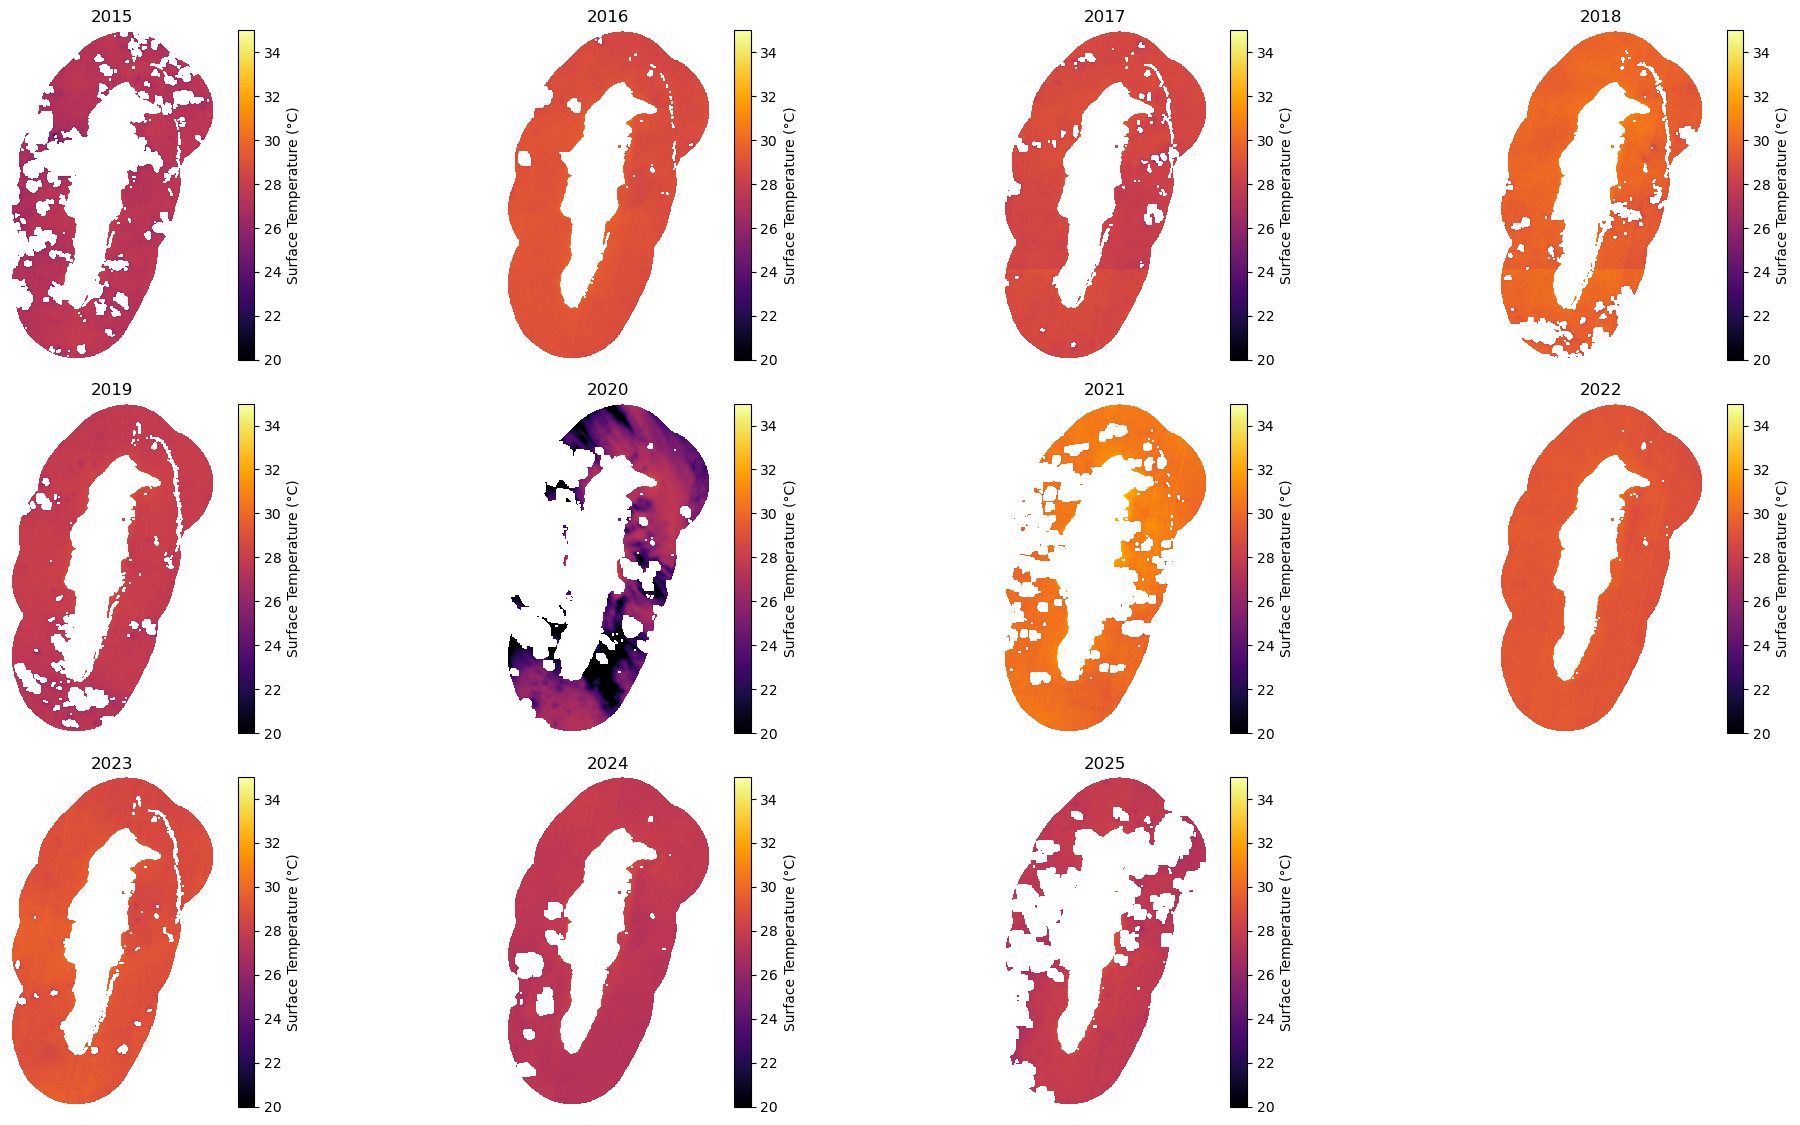

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

#load the TIFF files
mask_tiff = ["Buffer_San_Andres_2015_tif.tif",
             "Buffer_San_Andres_2016_tif.tif",
             "Buffer_San_Andres_2017_tif.tif",
             "Buffer_San_Andres_2018_tif.tif",
             "Buffer_San_Andres_2019_tif.tif",
             "Buffer_San_Andres_2020_tif.tif",
             "Buffer_San_Andres_2021_tif.tif",
             "Buffer_San_Andres_2022_tif.tif",
             "Buffer_San_Andres_2023_tif.tif",
             "Buffer_San_Andres_2024_tif.tif",
             "Buffer_San_Andres_2025_tif.tif",
            ]

dates = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]

#Scale Factors:
MULT, ADD = 0.00341802, 149.0

scenes = []
indices = [0,1,2,3,4,5,6,7,8,9,10]


#convert temps and visualize the data
for tif in mask_tiff:
    with rasterio.open(tif) as src:
        DN = src.read(1).astype("float32")
        #65535
        DN[DN==65535] = np.nan # remove not a number
        tempC = (DN * MULT + ADD) - 273.15
        scenes.append(tempC)

vmin = 20
vmax = 35

rows = 4
cols = 4

plt.figure(figsize = (20,15))
for i, idx in enumerate(indices):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(scenes[idx], cmap = "inferno", vmin=vmin, vmax=vmax)
    plt.title(dates[idx])
    plt.colorbar(label="Surface Temperature (°C)")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
stats = []

for date, img in zip(dates, scenes):
    stats.append({
        "date": date,
        "Mean": np.nanmean(img),
        "Min": np.nanmin(img),
        "Max": np.nanmax(img),
        "Standard Deviation": np.nanstd(img)
        })

df_stats = pd.DataFrame(stats)
print (df_stats)
df_stats.to_csv("sst_stats.csv", index = False)

    date       Mean        Min        Max  Standard Deviation
0   2015  27.203260  19.642670  37.006226            0.542517
1   2016  28.985018  26.929901  36.866089            0.373905
2   2017  28.489634  23.771637  33.830902            0.350473
3   2018  29.762367  23.371735  35.512543            0.436968
4   2019  27.819077  24.585144  33.704437            0.430443
5   2020  24.251854  10.116669  34.179535            2.772429
6   2021  30.376328  28.608154  37.286530            0.488931
7   2022  29.250839  28.543213  39.679108            0.300755
8   2023  29.021320  26.488983  36.476440            0.387124
9   2024  27.590658  26.188202  38.390533            0.382801
10  2025  27.726480  25.590057  33.878754            0.403739


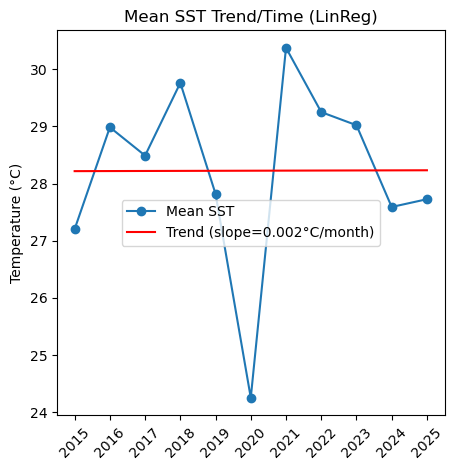

In [6]:
##Linear Regression test
from scipy.stats import linregress

x = np.arange(len(df_stats))
y = df_stats["Mean"].values

slope, intercept, r, p, stderr = linregress(x, y)

plt.figure(figsize = (5,5))
plt.plot(df_stats["date"], y, marker="o", label="Mean SST")
plt.plot(df_stats["date"], intercept + slope*x, 'r', label=f"Trend (slope={slope:.3f}°C/month)")

plt.xticks(rotation=45)
plt.ylabel("Temperature (°C)")
plt.title("Mean SST Trend/Time (LinReg)")
plt.legend()
plt.show()

Trend: no trend
H (True if trend is present): False
P-value: 1.0
Z-statistic: 0.0
Mann-Kendall S: -1.0
Variance of S: 165.0
Sen's slope: -0.01543267567952474
Intercept: 28.56679693857829


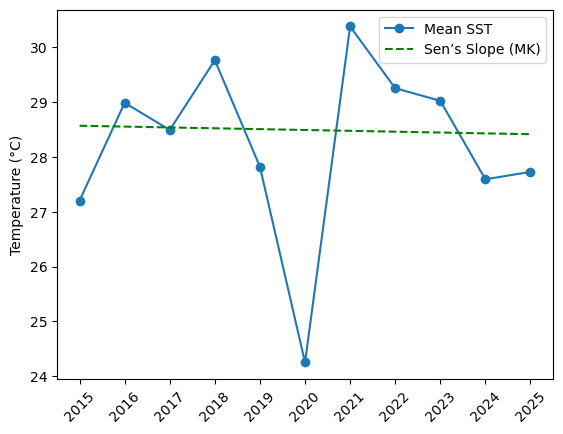

In [5]:
#Mann-Kendall Test
!pip install pymannkendall
import numpy as np
import pymannkendall as mk

data = df_stats["Mean"].values
y = df_stats["Mean"].values
years = df_stats["date"]


# Correct function name:
result = mk.original_test(data)

print(f"Trend: {result.trend}")
print(f"H (True if trend is present): {result.h}")
print(f"P-value: {result.p}")
print(f"Z-statistic: {result.z}")
print(f"Mann-Kendall S: {result.s}")
print(f"Variance of S: {result.var_s}")
print(f"Sen's slope: {result.slope}")
print(f"Intercept: {result.intercept}")

x_numeric = np.arange(len(y))

mk_result = mk.original_test(y)

sen_line = mk_result.intercept + mk_result.slope * x_numeric

plt.plot(years, y, 'o-', label="Mean SST")
plt.plot(years, sen_line, 'g--', label="Sen’s Slope (MK)")
plt.xticks(rotation=45)
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()